**Imports**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../data/processed', exist_ok=True)
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
import joblib

RANDOM_STATE = 42

df = pd.read_csv('../data/processed/application_processed.csv')
print(f"Loaded: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.2%}")

Loaded: (307511, 84)
Default rate: 8.07%


**Train/Test Split**

In [ ]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y        # preserves 8% default rate in both splits
)

print(f"Train: {X_train.shape} | Default rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}  | Default rate: {y_test.mean():.2%}")

Train: (246008, 83) | Default rate: 8.07%
Test:  (61503, 83)  | Default rate: 8.07%


**Scale Features**

In [ ]:
# Logistic regression requires scaling, tree models don't, but LR does
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # fit only on train, no leakage

print("Scaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete.
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0000


**Train Logistic Regression**

In [ ]:
lr = LogisticRegression(
    class_weight='balanced',   # handles 8% imbalance
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=0.01                     # regularization — prevents overfitting on 84 features
)

lr.fit(X_train_scaled, y_train)
print("Model trained.")

# Predictions
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]
y_pred       = lr.predict(X_test_scaled)

Model trained.


**Core Credit Risk Metrics**

In [ ]:
# AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)

# Gini coefficient (standard in credit scoring)
gini = 2 * auc - 1

# KS Statistic (Kolmogorov-Smirnov)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ks_stat = max(tpr - fpr)

# Average Precision (PR-AUC), better than ROC for imbalanced
ap = average_precision_score(y_test, y_pred_proba)

print("=" * 45)
print("LOGISTIC REGRESSION — BASELINE RESULTS")
print("=" * 45)
print(f"AUC-ROC  : {auc:.4f}")
print(f"Gini     : {gini:.4f}   ← 2×AUC−1, used in credit scoring")
print(f"KS Stat  : {ks_stat:.4f}   ← max separation between classes")
print(f"PR-AUC   : {ap:.4f}   ← precision-recall, imbalance-aware")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

LOGISTIC REGRESSION — BASELINE RESULTS
AUC-ROC  : 0.7476
Gini     : 0.4952   ← 2×AUC−1, used in credit scoring
KS Stat  : 0.3665   ← max separation between classes
PR-AUC   : 0.2288   ← precision-recall, imbalance-aware

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.96      0.69      0.80     56538
   Defaulted       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



**ROC and Precision-Recall Curves**

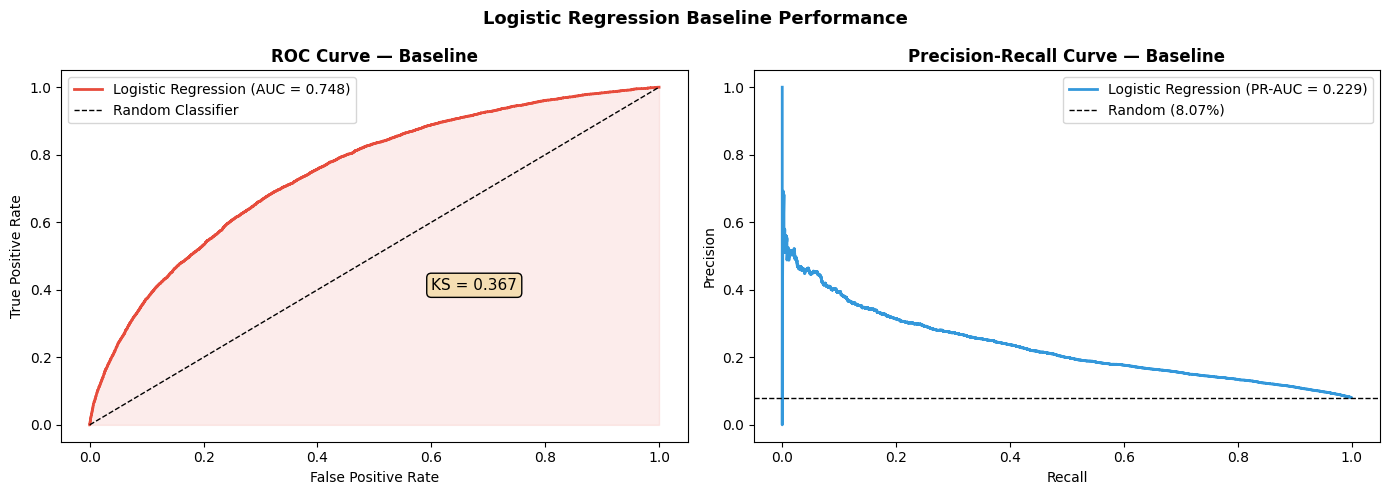

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'Logistic Regression (AUC = {auc:.3f})')
axes[0].plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Baseline', fontweight='bold')
axes[0].legend()
axes[0].annotate(f'KS = {ks_stat:.3f}', xy=(0.6, 0.4), fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='wheat'))

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='#3498db', lw=2,
             label=f'Logistic Regression (PR-AUC = {ap:.3f})')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Random ({y_test.mean():.2%})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Baseline', fontweight='bold')
axes[1].legend()

plt.suptitle('Logistic Regression Baseline Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/05_baseline_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

**Confusion Matrix**

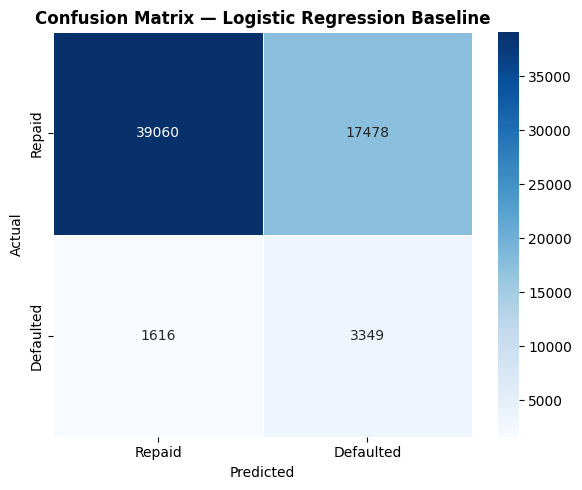

True Negatives  (correctly approved): 39,060
False Positives (wrongly rejected)  : 17,478
False Negatives (missed defaults)   : 1,616  ← costly
True Positives  (caught defaults)   : 3,349


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'],
            linewidths=0.5)
plt.title('Confusion Matrix — Logistic Regression Baseline', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/processed/06_baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly approved): {tn:,}")
print(f"False Positives (wrongly rejected)  : {fp:,}")
print(f"False Negatives (missed defaults)   : {fn:,}  ← costly")
print(f"True Positives  (caught defaults)   : {tp:,}")

**Top Predictive Features**

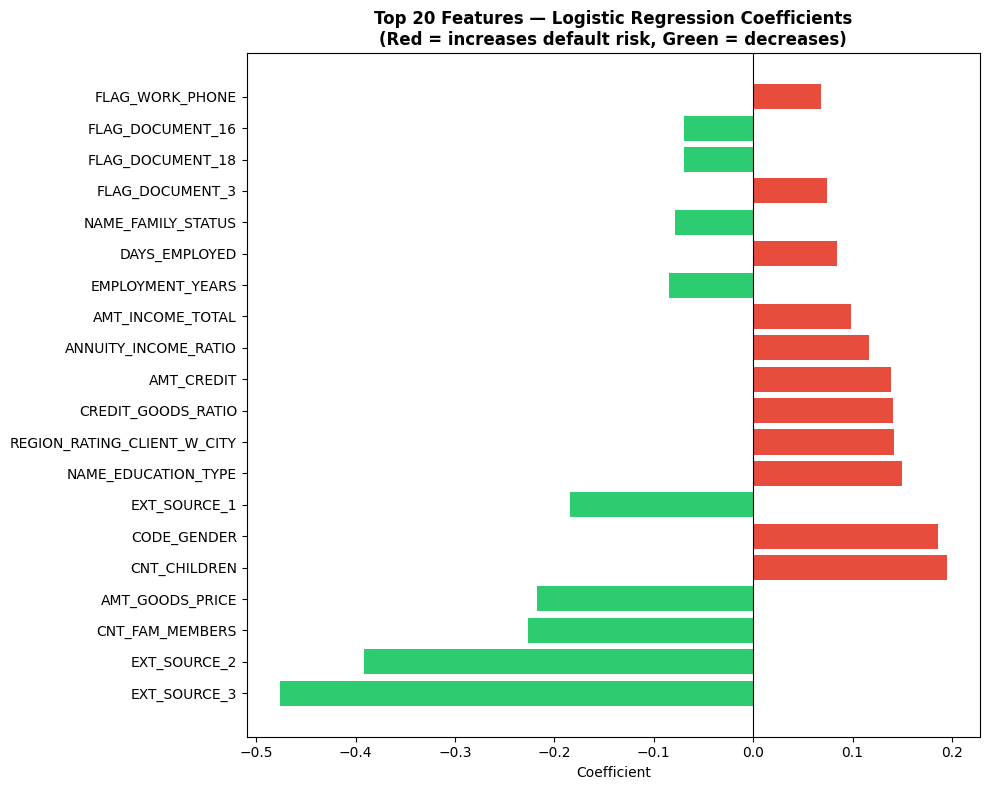

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
}).assign(abs_coef=lambda x: x['coefficient'].abs()
).sort_values('abs_coef', ascending=False).head(20)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' 
          for c in feature_importance['coefficient']]
plt.barh(feature_importance['feature'], 
         feature_importance['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features — Logistic Regression Coefficients\n'
          '(Red = increases default risk, Green = decreases)', fontweight='bold')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('../data/processed/07_baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Save Baseline Model**

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(lr,     '../models/logistic_regression_baseline.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Saved:")
print("  → models/logistic_regression_baseline.pkl")
print("  → models/scaler.pkl")

print("\n" + "=" * 45)
print("BASELINE SUMMARY")
print("=" * 45)
print(f"Model    : Logistic Regression (class_weight=balanced)")
print(f"AUC-ROC  : {auc:.4f}")
print(f"Gini     : {gini:.4f}")
print(f"KS Stat  : {ks_stat:.4f}")
print(f"PR-AUC   : {ap:.4f}")
print("=" * 45)
print("Next: XGBoost Champion Model")

Saved:
  → models/logistic_regression_baseline.pkl
  → models/scaler.pkl

BASELINE SUMMARY
Model    : Logistic Regression (class_weight=balanced)
AUC-ROC  : 0.7476
Gini     : 0.4952
KS Stat  : 0.3665
PR-AUC   : 0.2288
Next: XGBoost Champion Model
